In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/SiddardhaShayini/Cyber-Crime-Analysis-and-Prediction-in-India/refs/heads/main/datasets/processed_dataset.csv'
df = pd.read_csv(url)

# **Gradient Boosting Regressor**

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
# Features and target
features = [
    "State/UT_encoded", "Total", "Total-Scale",
    "Mean_2002_2021", "Std_2002_2021", "YoY_2021"
] + [str(year) for year in range(2002, 2022)]
target = "2021"

In [5]:
X = df[features]
y = df[target]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Check for small y_test values
print("Min y_test value:", y_test.min())
print("Count of y_test values < 1000:", (y_test < 1000).sum())

Min y_test value: 5
Count of y_test values < 1000: 5


In [9]:
# Initialize and train the model
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [10]:
# Make predictions
y_pred = gbr_model.predict(X_test)


In [11]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
mape = (abs((y_test - y_pred) / y_test).mean()) * 100

In [12]:
print(f"Model: Gradient Boosting Regressor")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Model: Gradient Boosting Regressor
Mean Absolute Error (MAE): 226.05
Root Mean Squared Error (RMSE): 299.33
R² Score: 1.00
Mean Absolute Percentage Error (MAPE): 388.54%


### Gradient Boosting Regressor

| Metric                        | Value       |
|------------------------------|-------------|
| **MAE**                      | 226.05   |
| **RMSE**                     | 299.33    |
| **R² Score**                 | 1.00        |
| **MAPE**                     | 388.54%     |



# **Tune Gradient Boosting**

In [13]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [14]:
# Check for small y_test values
print("Min y_test value:", y_test.min())
print("Count of y_test values < 1000:", (y_test < 1000).sum())

Min y_test value: 5
Count of y_test values < 1000: 5


In [15]:
# SMAPE function
def smape(y_true, y_pred):
    return 100 / len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))


In [16]:
# Hyperparameter tuning
param_dist = {
    "n_estimators": randint(100, 500),
    "learning_rate": uniform(0.01, 0.3),
    "max_depth": randint(3, 10),
    "subsample": uniform(0.6, 0.4)
}

In [17]:
gbr = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=1
)


In [18]:
# Fit on training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=50, n_jobs=1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d9d4ef24e90>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d9d4ef19090>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d9d4ef24dd0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d9d4ef25cd0>},
                   random_state=42, scoring='neg_mean_absolute_error')

In [19]:
# Best model
best_gbr = random_search.best_estimator_

In [20]:
# Predict
y_pred_best_gbr = best_gbr.predict(X_test)


In [21]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_best_gbr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_gbr))
r2 = r2_score(y_test, y_pred_best_gbr)
smape_value = smape(y_test, y_pred_best_gbr)

In [22]:
# Report
print("Tuned Gradient Boosting Results:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"SMAPE: {smape_value:.2f}%")

Tuned Gradient Boosting Results:
MAE: 333.33
RMSE: 423.88
R² Score: 1.00
SMAPE: 56.01%


### 🔍 Comparison of Models

| Metric   | ✅ Gradient Boosting | 🎯 Tuned Gradient Boosting |
|----------|---------------------|-----------------------------|
| **MAE**  | ✅ **226.05 (Better)** | 333.33 |
| **RMSE** | ✅ **299.33 (Better)** | 423.88 |
| **R²**   | ✅ **1.00**             | 1.00 |
| **MAPE** | 🚫 388.54% (Very High) | ✅ **SMAPE: 56.01% (Much Better)** |

---
- The **original Gradient Boosting** gives **very low MAE and RMSE**, indicating it fits the data **very tightly** — possibly even **overfitting**.
- But look at the **MAPE**: a **huge 388.54%**, meaning it performs **very poorly on smaller values**.
- On the other hand, the **Tuned Gradient Boosting** has slightly **worse MAE/RMSE**, but the **SMAPE (56.01%)** is **way better**, showing it's **more reliable**, especially when dealing with both large and small targets.

---

### ✅ Final Model

> **Tuned Gradient Boosting**.

Why?
- Better generalization.
- SMAPE is more reliable when targets vary in scale.
- It’s safer and more robust for real-world prediction.


In [24]:
import joblib
from google.colab import files

In [25]:
# Save the tuned model
joblib.dump(best_gbr, 'tuned_gradient_boosting_model.pkl')

['tuned_gradient_boosting_model.pkl']

In [26]:
# Download the file
files.download('tuned_gradient_boosting_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

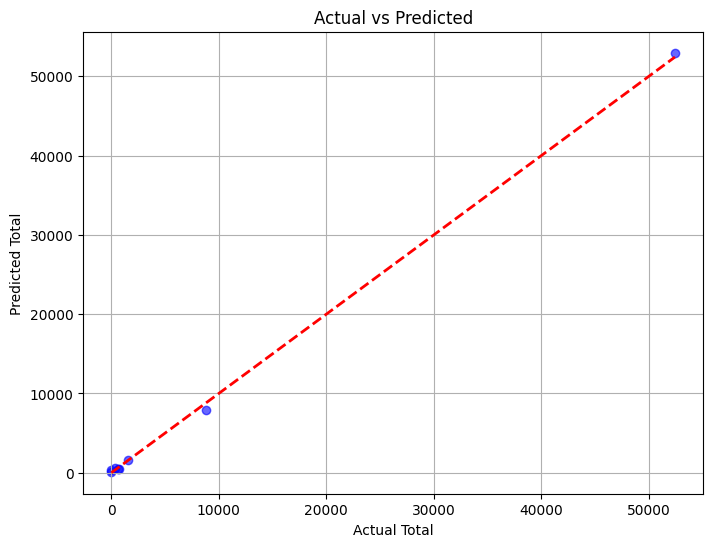

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total')
plt.ylabel('Predicted Total')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()


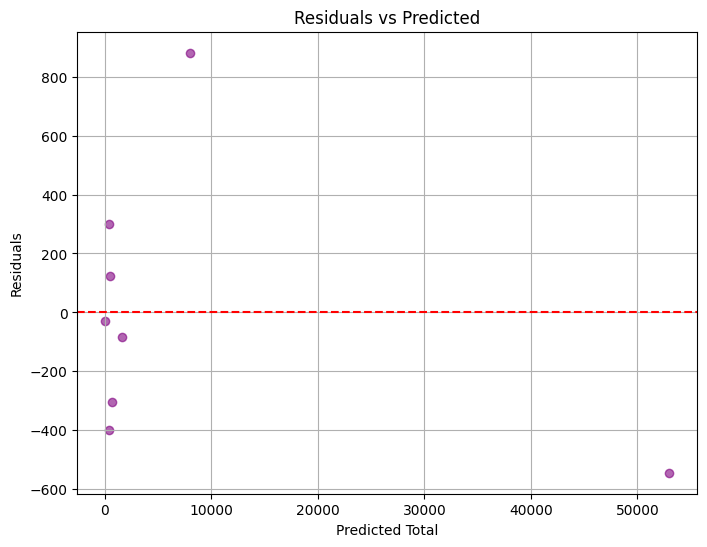

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Total')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.grid(True)
plt.show()


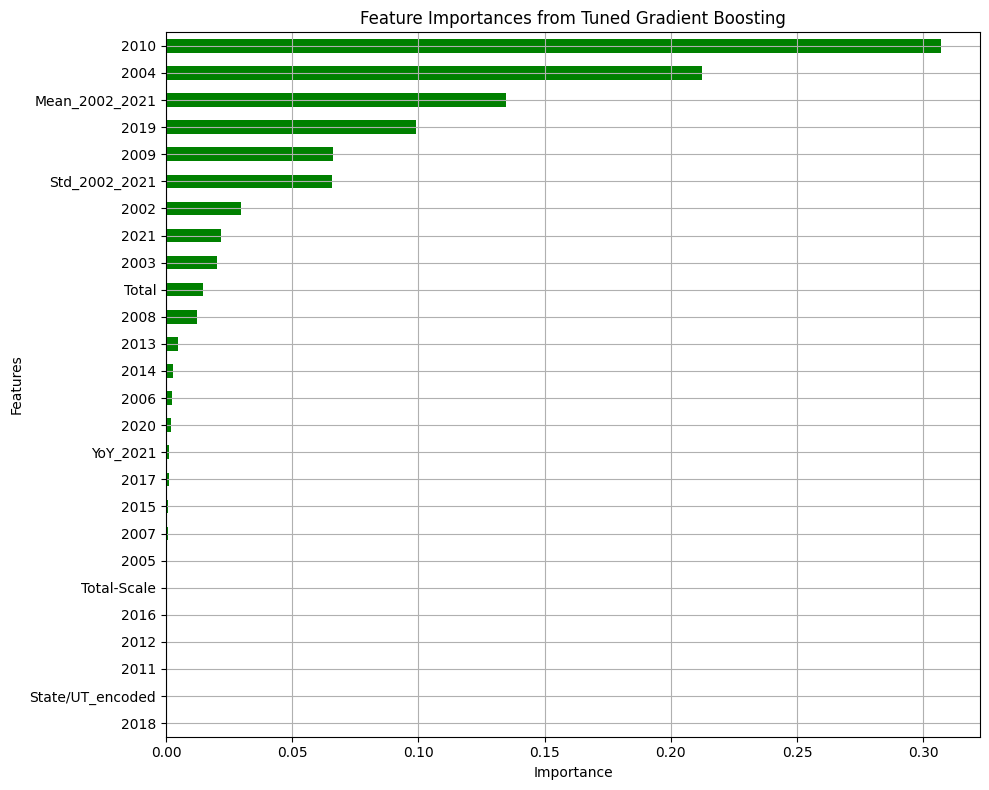

In [30]:
import pandas as pd

feature_importance = pd.Series(tuned_gbr.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh', color='green')
plt.title('Feature Importances from Tuned Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(True)
plt.tight_layout()
plt.show()


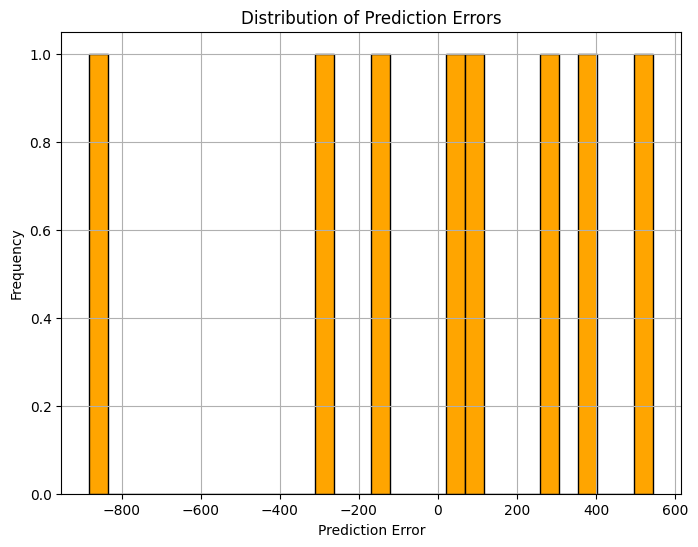

In [31]:
error = y_pred - y_test

plt.figure(figsize=(8, 6))
plt.hist(error, bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


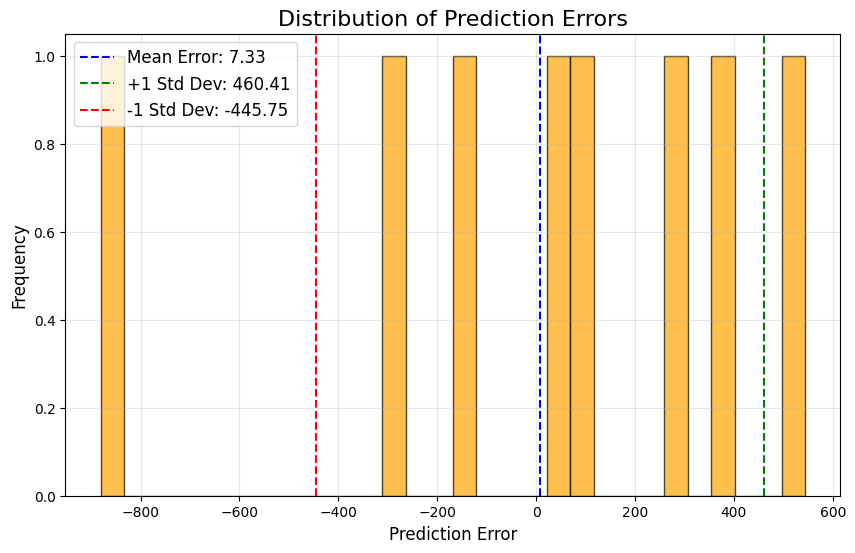

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate prediction errors
errors = y_pred_best_gbr - y_test

# Create the histogram plot
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, color='orange', edgecolor='black', alpha=0.7)

# Calculate mean and standard deviation of errors
mean_error = errors.mean()
std_error = errors.std()

# Add mean and standard deviation lines
plt.axvline(mean_error, color='blue', linestyle='dashed', linewidth=1.5, label=f"Mean Error: {mean_error:.2f}")
plt.axvline(mean_error + std_error, color='green', linestyle='dashed', linewidth=1.5, label=f"+1 Std Dev: {mean_error + std_error:.2f}")
plt.axvline(mean_error - std_error, color='red', linestyle='dashed', linewidth=1.5, label=f"-1 Std Dev: {mean_error - std_error:.2f}")

# Add labels, title, and grid
plt.title("Distribution of Prediction Errors", fontsize=16)
plt.xlabel("Prediction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

In [32]:
import plotly.express as px
import pandas as pd

df_plot = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

fig = px.scatter(df_plot, x='Actual', y='Predicted',
                 title='Actual vs Predicted (Plotly)',
                 labels={'Actual': 'Actual Total', 'Predicted': 'Predicted Total'},
                 trendline="ols", opacity=0.7)
fig.add_shape(type='line',
              x0=y_test.min(), y0=y_test.min(),
              x1=y_test.max(), y1=y_test.max(),
              line=dict(color='red', dash='dash'))
fig.show()


In [33]:
import numpy as np

residuals = y_test - y_pred
df_resid = pd.DataFrame({'Predicted': y_pred, 'Residuals': residuals})

fig = px.scatter(df_resid, x='Predicted', y='Residuals',
                 title='Residuals vs Predicted (Plotly)',
                 labels={'Predicted': 'Predicted Total', 'Residuals': 'Error'},
                 opacity=0.7)
fig.add_shape(type='line', x0=df_resid['Predicted'].min(), y0=0,
              x1=df_resid['Predicted'].max(), y1=0,
              line=dict(color='red', dash='dash'))
fig.show()



In [34]:
feat_imp = pd.Series(tuned_gbr.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True).reset_index()
feat_imp.columns = ['Feature', 'Importance']

fig = px.bar(feat_imp, x='Importance', y='Feature', orientation='h',
             title='Feature Importances (Plotly)',
             labels={'Importance': 'Importance Score', 'Feature': 'Features'})
fig.update_layout(yaxis=dict(categoryorder='total ascending'))
fig.show()


In [35]:
error = y_pred - y_test

fig = px.histogram(error, nbins=30, title='Distribution of Prediction Errors',
                   labels={'value': 'Error', 'count': 'Frequency'},
                   opacity=0.75)
fig.update_traces(marker=dict(color='orange', line=dict(width=1, color='black')))
fig.show()

